# Synthetic Track Generation and Day-Night Merging Pipeline

## Overview
This document outlines the workflow for generating synthetic Clear Sky Index (CSI) estimation during nighttime with GUM Generator. By applying the GUM to nocturnal satellite bands and subsequently merging these estimation with daytime ground-truth CAMS data, the pipeline constructs a continuous and hourly time series.

---

## 1. Model Initialization and Data Loading
The pipeline initializes the pre-trained GUM model and prepares the global normalization metrics required for inference.

* **Model Checkpoint:** `Model_checkpoint/best_gum.pt`
* **Model Configuration:** `GUM(feature_size=64, K=2, gate_temp=0.5)`
* **Normalization Stats:** Loaded from `Data/static/minmax_strat.npz` (calculated exclusively from daytime training data).

## 2. Nighttime Feature Engineering
The raw nighttime satellite observations are aligned with static geographic and elevation maps to build the evaluation tensors.

* **Input Data:** `bands_night_paired_twillight.npz`
* **Static Maps:** `hk_geom_50x50.npz`
* **Bands Used:** 10 channels (`tbb_08` through `tbb_16`, plus `SAZ`)
* **Output Tensor:** `bands_night_pairs_with_elevation.npz`

## 3. Synthetic CSI Inference
The pipeline processes the prepared nighttime synthetic CSI through the GUM architecture in evaluation mode (`torch.no_grad()`) to generate synthetic CSI estimations. 

* **Batch Size:** 64
* **Output Export:** The synthetic nocturnal CSI arrays are saved sequentially to `csi_synthetic_hourly_night_fuzzy_pub.npz`.

## 4. Continuous Timeline Integration
To create a seamless diurnal and nocturnal time series, the predicted nighttime CSI is merged with the true daytime CSI derived from CAMS data.

* **Daytime Processing:**
  * **Input:** `cams_day_paired_no_twillight.npz`
  * **CSI Calculation:** $CSI = \frac{GHI}{GHI_{ClearSky}}$
  * **Data Protection:** A lower-bound epsilon (`1e-6`) is applied to $GHI_{ClearSky}$ to prevent division by zero errors.
* **Merging Process:**
  * Daytime truth arrays and nighttime prediction arrays are concatenated and chronologically sorted using their respective epoch timestamp arrays.
  * Hourly aggregation and temporal alignment are performed via `merge_day_night_on_time_hourly`.

### Final Dataset Statistics
> * **Temporal Range:** `2021-01-01 10:30:00` to `2023-12-31 23:40:00`
> * **Total Frames:** 105,513
> * **Daytime Samples (Truth):** 46,277
> * **Nighttime/Twilight Samples (Synthetic):** 59,236

## 5. Visual Verification
The merged dataset is validated visually using customized plotting tools (`plot_syn_csi`). This function generates sequential, multi-axis visualizations of the continuous CSI tracks to ensure boundary smoothness and diurnal consistency between daytime ground truth and nighttime predictions.

In [17]:
%load_ext autoreload
%autoreload 2
import torch
import numpy as np
from src.data_preprocessing import(
    build_band_tensor_with_elevation,
)
from src.bands_and_cams import(
    load_bands_and_cams,
)
from src.dataset import(
    BandsCamsDataset,
)
from src.plot import(
    plot_csi_sorted_sequence_exact,plot_syn_csi
)
from torch.utils.data import DataLoader
from src.utils import crop_back, pad_to_32,merge_day_night_on_time, merge_day_night_on_time_hourly

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1. Model Initialization and Data Loading

In [2]:
from src.model import GUM 
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
torch.cuda.set_device(0)
model = GUM(feature_size=64, K=2, gate_temp=0.5).to(device)
PATH = "Model_checkpoint/best_gum.pt"
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
sd = torch.load(PATH, map_location=device)["model"]
if any(k.startswith("_orig_mod.") for k in sd.keys()):
    sd = {k.replace("_orig_mod.", ""): v for k, v in sd.items()}
model.load_state_dict(sd)
model.to(device)
print("Model loaded successfully.")

Model loaded successfully.


In [ ]:
minmax =  np.load("Data/static/minmax_strat.npz")
channel_min, channel_max = minmax["channel_min"], minmax["channel_max"]
# load night data with elevation and landmask
bands_npz_name = "Data/bands/modeldata/bands_night_paired_twillight.npz"
elevation_npz_name = "Data/elevation/hk_geom_50x50.npz"

## 2. Nighttime Feature Engineering

In [4]:
bands_used = [
    'tbb_08','tbb_09','tbb_10','tbb_11','tbb_12',
    'tbb_13','tbb_14','tbb_15','tbb_16','SAZ'
]
shape, out = build_band_tensor_with_elevation(
    bands_npz_name=bands_npz_name,
    elevation_npz_name=elevation_npz_name,
    bands_used=bands_used,
    output_path="Data/output/bands_night_pairs_with_elevation.npz",
)

In [7]:
X_test, y_test = load_bands_and_cams(
    bands_npz_path="Data/output/bands_night_pairs_with_elevation.npz",
    cams_npz_path="Data/CAMS/modeldata/cams_night_paired_twillight.npz",
    bands_indices_used=None,  
    eps=1e-6,
    verbose=False,
)

In [6]:
night_dataset  = BandsCamsDataset(X_test,  y_test,  channel_min, channel_max,
                                 elev_ch_idx=-2, land_ch_idx=-1)
night_loader  = DataLoader(night_dataset,  batch_size=64, shuffle=False)

## 3. Synthetic CSI Inference

In [ ]:
# save synthetic night CSI
y_pred = []
model.eval()
with torch.no_grad():
    for x_batch, y_batch in night_loader:
        x_batch = x_batch.to(device)
        xb_pad, h, w = pad_to_32(x_batch)

        pred_y = model(xb_pad)
        if isinstance(pred_y, (tuple, list)):
            pred_y = pred_y[0]
            pred_y = crop_back(pred_y, h, w).contiguous()
            y_pred.append(pred_y.cpu().numpy())
y_pred = np.concatenate(y_pred, axis=0)

out_path = "Data/syntheticCSI/csi_synthetic_hourly_night_fuzzy_pub.npz"
night_t    = np.load(bands_npz_name)["time_min"]
np.savez_compressed(
    out_path,
    csi=y_pred,
    time_hourly=night_t,
)

In [8]:
data= np.load("Data/syntheticCSI/csi_synthetic_hourly_night_fuzzy_pub.npz")
y_pred = data["csi"]
night_t = data["time_hourly"]

In [ ]:
out_path = "Data/syntheticCSI/csi_synthetic_hourly_night_fuzzy_pub.npz"
# --- DAY truth CSI from CAMS (ghi_grid2500_2ch_day.npz) ---
cams_day_npz = np.load("Data/CAMS/modeldata/cams_day_paired_no_twillight.npz", allow_pickle=True)
cams_day     = cams_day_npz["data"].astype(np.float32)   # (T_day, 2, 50, 50)
time_day     = cams_day_npz["time_min"]                      # (T_day,)
# load bands for time info only
night_t    = np.load(out_path)["time_hourly"]
eps = 1e-6
ghi_day    = cams_day[:, 0, :, :]  # (T_day, 50, 50)
ghi_cs_day = cams_day[:, 1, :, :]  # (T_day, 50, 50)

ghi_cs_safe = np.where(ghi_cs_day < eps, eps, ghi_cs_day)
csi_day = ghi_day / ghi_cs_safe                   # (T_day, 50, 50)
y_true_day = csi_day[:, None, :, :]               # (T_day, 1, 50, 50)
print("y_true_day:", y_true_day.shape)
print("y_pred_night:", night_t.shape)

y_true_day: (67638, 1, 50, 50)
y_pred_night: (59236,)


## 4. Continuous Timeline Integration

In [10]:
csi_sorted, time_sorted, is_day_sorted = merge_day_night_on_time(
    y_true_day, time_day,
    y_pred, night_t
)
print("sorted time range:", time_sorted[0], "→", time_sorted[-1])
print("frames:", len(time_sorted), "day:", is_day_sorted.sum(), "night:", (~is_day_sorted).sum())

sorted time range: 2021-01-01 10:30:00 → 2023-12-31 23:40:00
frames: 105513 day: 46277 night: 59236


In [ ]:
csi_h, hours, is_day_h = merge_day_night_on_time_hourly(
    y_true_day, time_day, y_pred, night_t
)
# np.savez_compressed(
#     "Data/syntheticCSI/csi_synthetic_hourly_merged_day_night_fuzzy_pub.npz",
#     csi=csi_h,
#     time_hourly=hours,
# )

## 5. Visual Verification

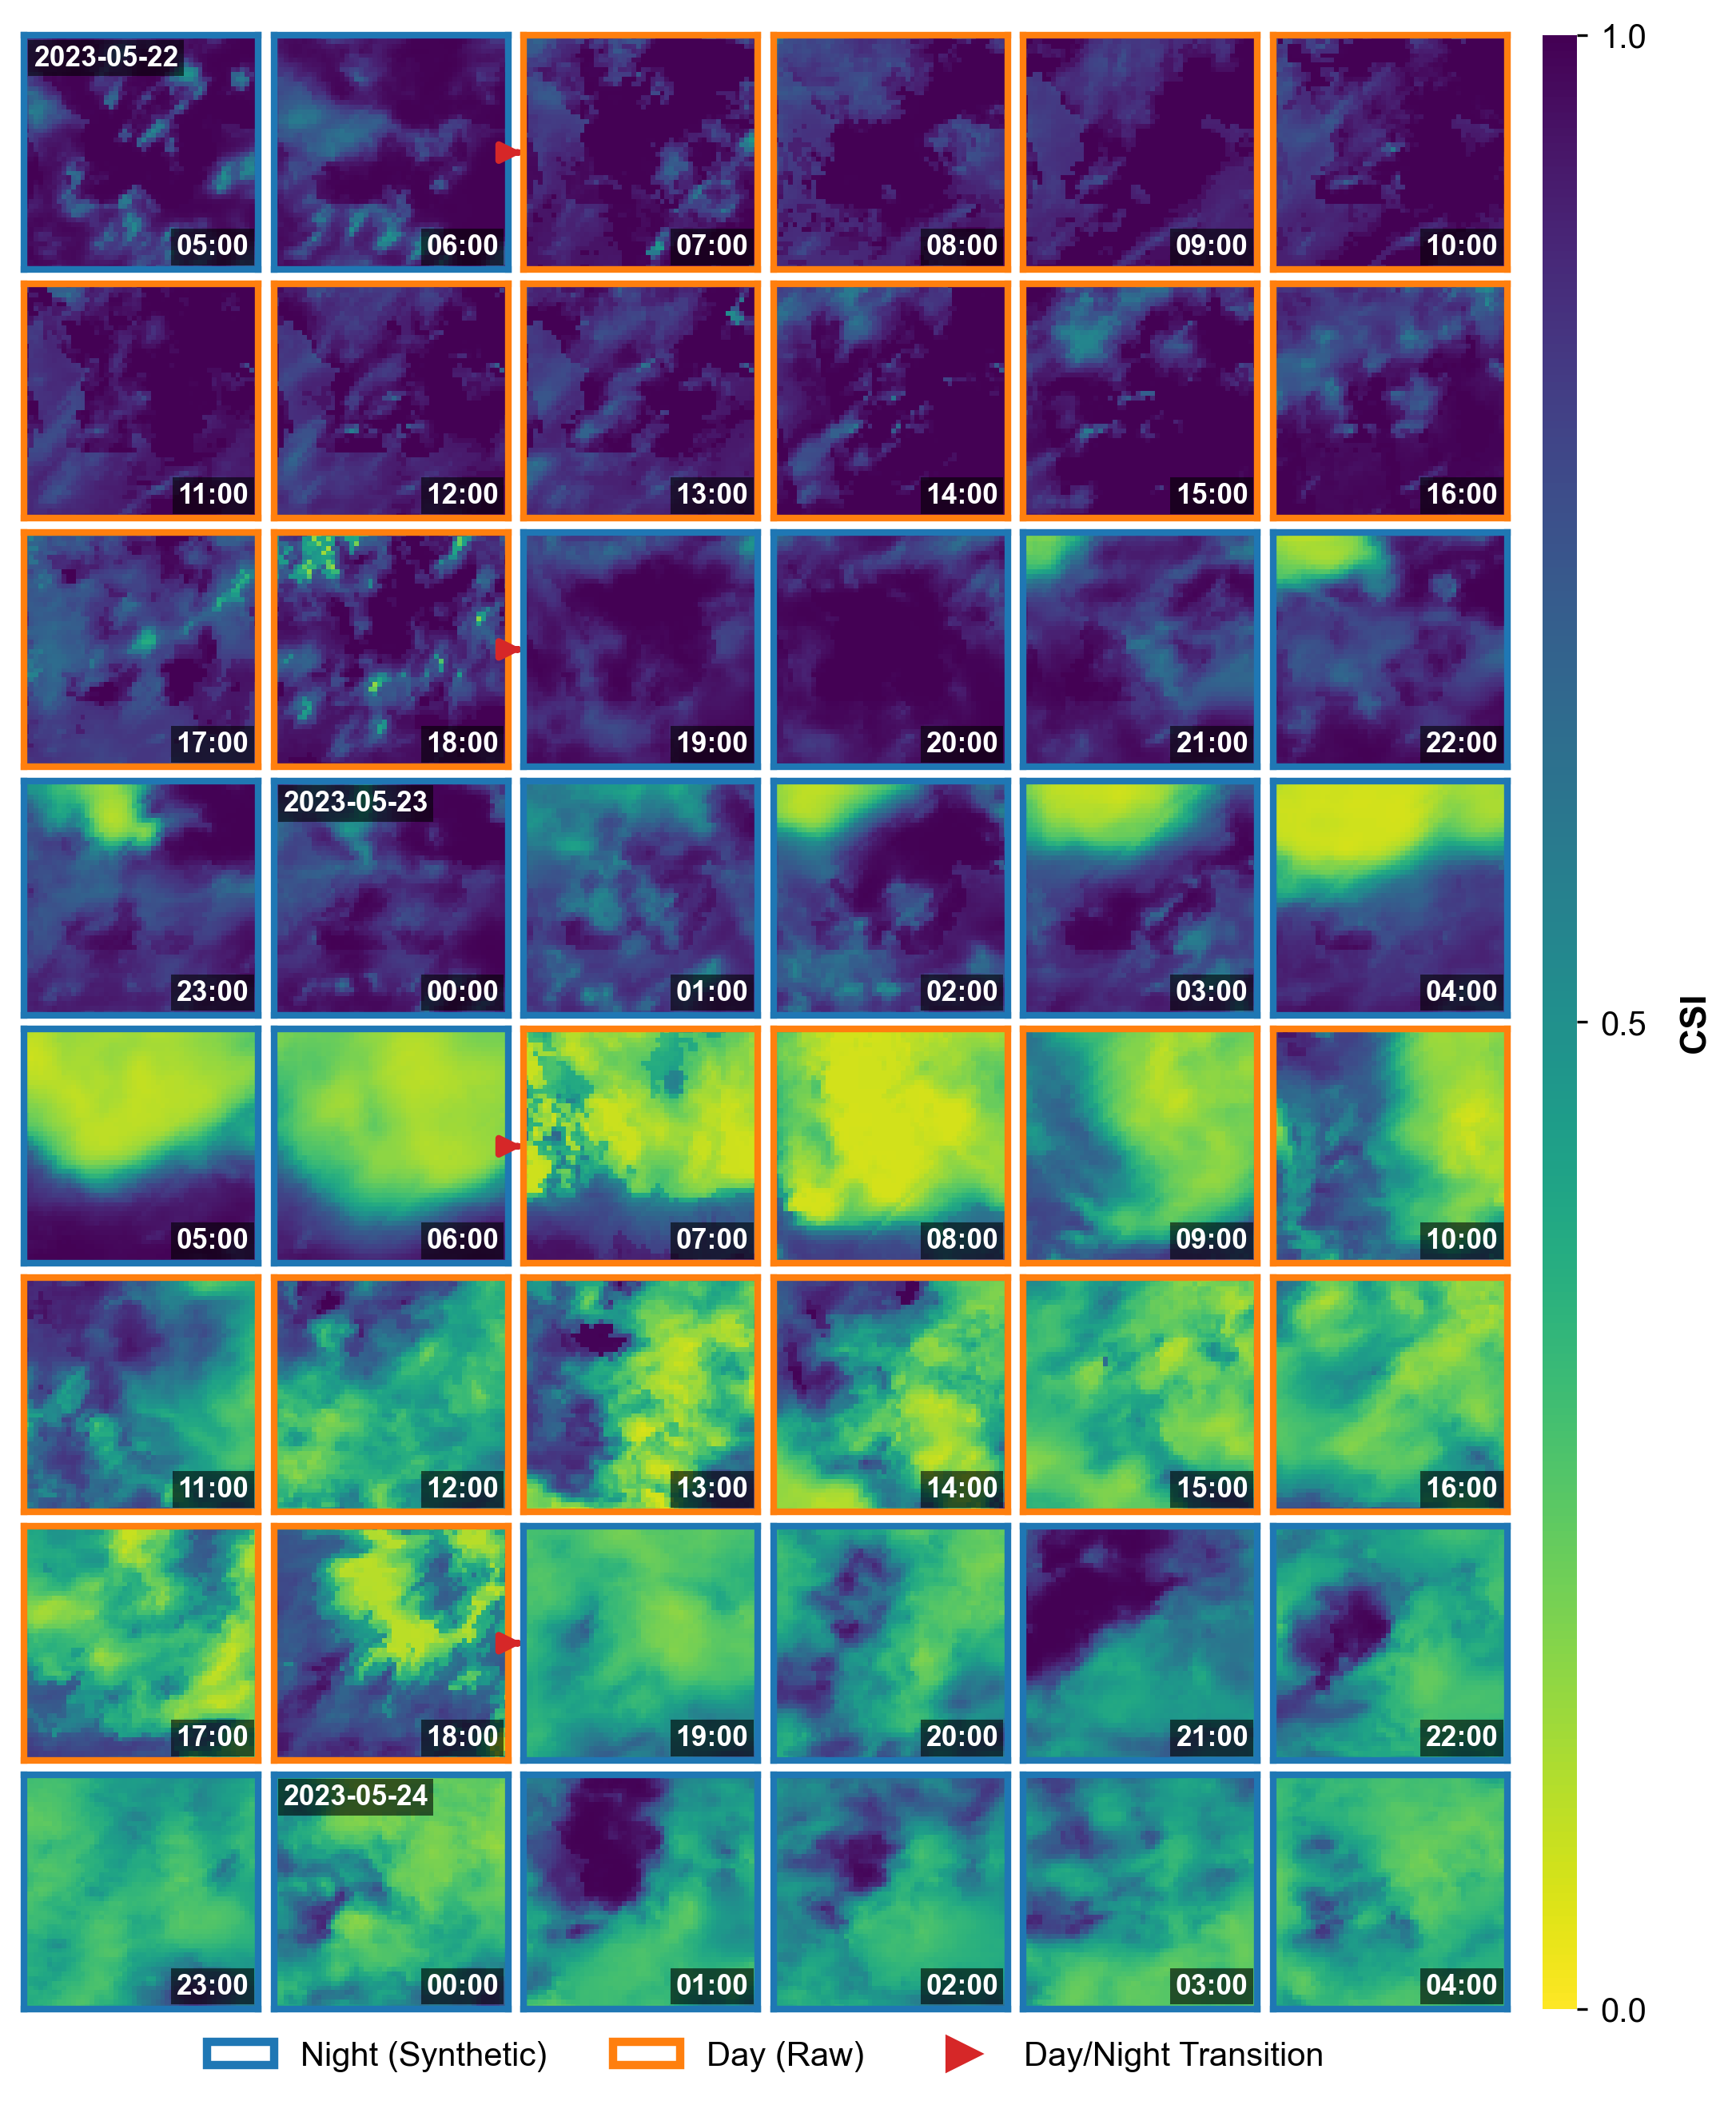

In [15]:
plot_syn_csi(csi_h, hours, is_day_h, start_idx=20496+(24*11), num_steps=48)